# Data Loading & Initial Inspection

## Import important libraries (pandas, numpy, matplotlib, seaborn, sklearn).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

## Load healthcare-dataset-stroke-data.csv into DataFrame df

In [3]:
df = pd.read_csv('./data/raw/healthcare-dataset-stroke-data.csv')



## Display first 5 rows using df.head()

In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
## Use df.info() to check data types, non-null values, memory usage

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


## Use df.describe() for statistical summaries

In [8]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


# Exploratory Data Analysis & Visualization

## Create countplot for stroke column (class distribution)

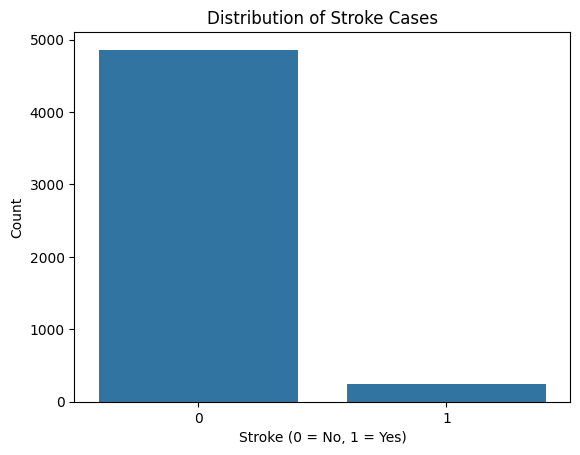

In [9]:
countplot_stroke = sns.countplot(x='stroke', data=df)
# set title and labels
countplot_stroke.set_title('Distribution of Stroke Cases')
countplot_stroke.set_xlabel('Stroke (0 = No, 1 = Yes)')
countplot_stroke.set_ylabel('Count')
# create new file and save the plot
plt.savefig('./output/plots/stroke_distribution.png')
plt.show()

## Create countplots with hue='stroke' for gender, work_type, smoking_status using subplots

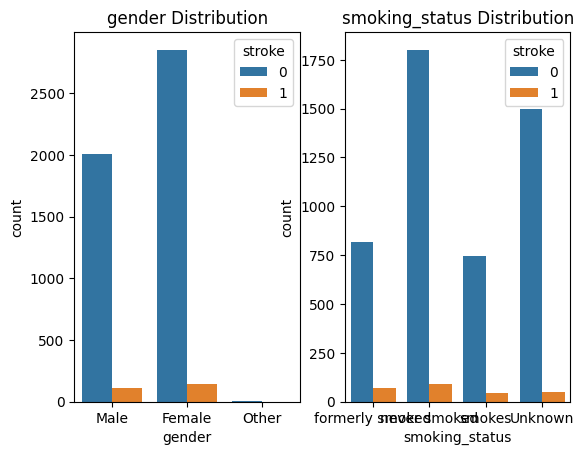

In [10]:
fig, ax = plt.subplots(1, 2)

ax[0].set_title('gender Distribution')
ax[0].set_xlabel('gender')

ax[1].set_title('smoking_status Distribution')
ax[1].set_xlabel('smoking_status')
# make x to be slope for x axis and stroke for hue
# ax[1].set_xticklabels(ax[1].get_yticklabels(), rotation=45)
# make stroke distribution plot
sns.countplot(x='gender', data=df, ax=ax[0],hue='stroke')
# make smoking distribution plot
sns.countplot(x='smoking_status', data=df, ax=ax[1],hue='stroke')

# save the plot
plt.savefig('./output/plots/smoking_and_gender_distribution.png')
plt.show()

## Drop 'Other' gender record (only 1 exists)

In [11]:
# Drop 'Other' gender record (only 1 exists)
df2 = df[df['gender'] != 'Other']
# save it to a new file
df2.to_csv('./data/proccessed/gender_filterd.csv', index=False)
df2.info()

<class 'pandas.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5109 non-null   int64  
 1   gender             5109 non-null   str    
 2   age                5109 non-null   float64
 3   hypertension       5109 non-null   int64  
 4   heart_disease      5109 non-null   int64  
 5   ever_married       5109 non-null   str    
 6   work_type          5109 non-null   str    
 7   Residence_type     5109 non-null   str    
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4908 non-null   float64
 10  smoking_status     5109 non-null   str    
 11  stroke             5109 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 677.4 KB


## Create histograms/KDE plots for age, avg_glucose_level, bmi using subplots

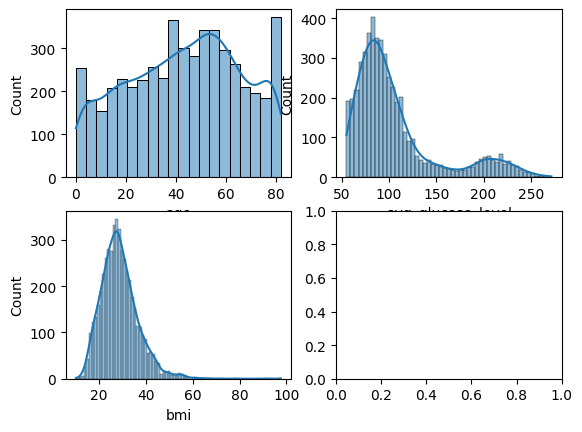

In [12]:
fix, ax = plt.subplots(2, 2)
sns.histplot(x='age', data=df2, ax=ax[0][0], kde=True)
sns.histplot(x='avg_glucose_level', data=df2, ax=ax[0][1], kde=True)
sns.histplot(x='bmi', data=df2, ax=ax[1][0], kde=True)

# save the plot
plt.savefig('./output/plots/age_glucose_bmi_distribution.png')
plt.show()

## Create correlation heatmap using selected numerical features and stroke

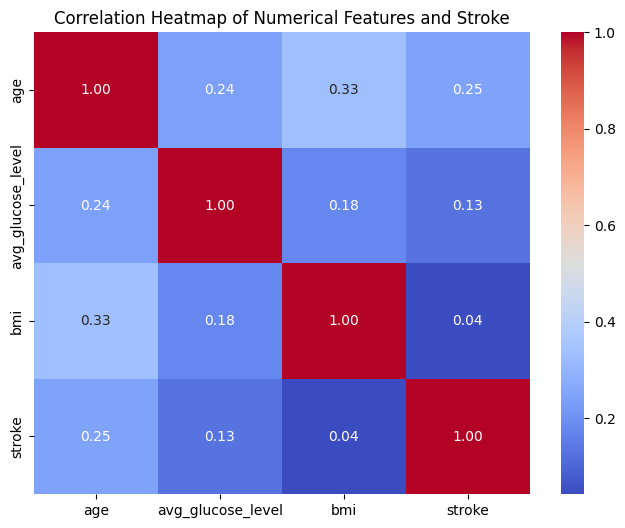

In [13]:
# Create correlation heatmap using selected numerical features and stroke
numerical_features = ['age', 'avg_glucose_level', 'bmi', 'stroke']
correlation_matrix = df2[numerical_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features and Stroke')
# save the plot
plt.savefig('./output/plots/correlation_heatmap.png')

# Data Preprocessing (Cleaning)

## Check for missing values using df.isnull().sum()

In [14]:
df.isnull().sum()


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

## Fill bmi missing values using mean or median

In [15]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())


In [16]:
## Verify no missing values remain
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

## Check for duplicates and remove them if any exist

In [17]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


In [18]:
df.duplicated().sum()

np.int64(0)

## Drop id column (no predictive power)

In [19]:
# Drop id column (no predictive power)
df = df.drop(columns=['id'])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


## Create boxplot for avg_glucose_level to detect outliers and remove if needed

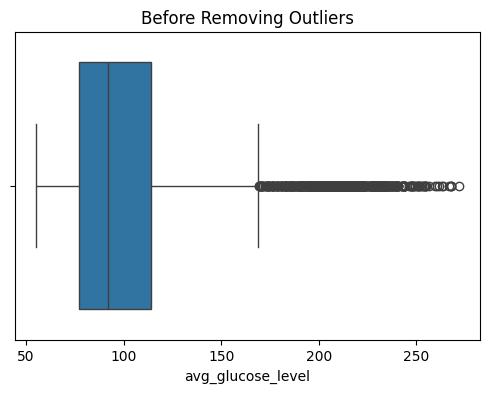

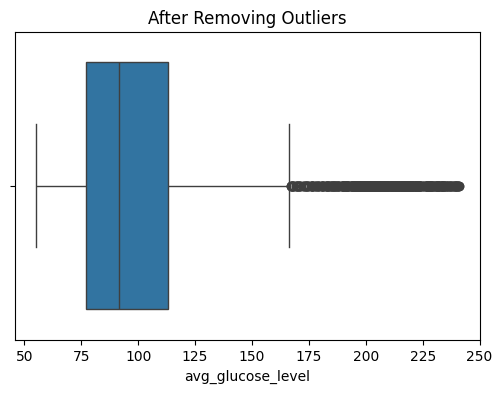

In [20]:
# Boxplot قبل إزالة الـ outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['avg_glucose_level'])
plt.title("Before Removing Outliers")
plt.show()

# حساب z-score
df['z_score_glucose'] = (
    (df['avg_glucose_level'] - df['avg_glucose_level'].mean()) 
    / df['avg_glucose_level'].std()
)

# إزالة الـ outliers باستخدام threshold = 3
df_no_outliers = df[df['z_score_glucose'].abs() < 3].copy()

# حذف عمود z_score لأنه مش محتاجه في الموديل
df_no_outliers.drop(columns=['z_score_glucose'], inplace=True)

# Boxplot بعد إزالة الـ outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_no_outliers['avg_glucose_level'])
plt.title("After Removing Outliers")
plt.show()

# حفظ الداتا بعد التنضيف
df_no_outliers.to_csv('./data/proccessed/cleaned_data_from_outliers.csv', index=False)

<Axes: xlabel='avg_glucose_level'>

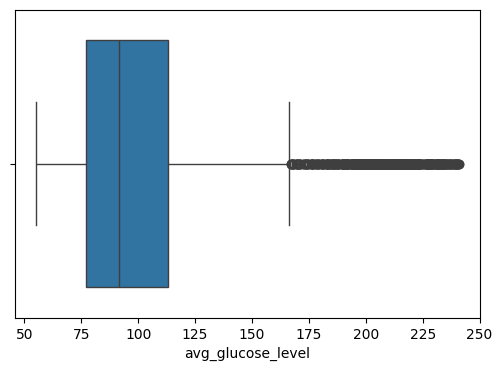

In [21]:
# Create boxplot for avg_glucose_level to detect outliers and remove if needed
plt.figure(figsize=(6, 4))
# import file from files 
df_no_outliers = pd.read_csv('./data/proccessed/cleaned_data_from_outliers.csv')
sns.boxplot(x=df_no_outliers['avg_glucose_level'])

## Separate features X and target y

### Separate features X and target y

In [22]:
x = df_no_outliers.drop(columns=['stroke']) 
y = df_no_outliers['stroke']




In [23]:
###  Use train_test_split() with 80/20 ratio and random_state=42

In [24]:
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(
    x, y, test_size=0.2, random_state=42)
x_train.head()


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
1168,Male,43.0,0,0,Yes,Govt_job,Urban,210.94,31.3,never smoked
2059,Male,47.0,0,0,No,Private,Rural,101.99,36.3,never smoked
2394,Male,65.0,1,0,Yes,Self-employed,Urban,113.86,36.4,never smoked
1534,Male,12.0,0,0,No,children,Rural,127.25,28.2,Unknown
3722,Female,62.0,0,0,Yes,Private,Urban,101.19,23.4,never smoked


### Verify shapes of X_train, X_test, y_train, y_test

In [25]:

print("Training set size:", x_train.shape)
print("Testing set size:", y_train.shape)
print("train data", x_test.shape)
print("train data", y_test.shape)

Training set size: (4048, 10)
Testing set size: (4048,)
train data (1013, 10)
train data (1013,)


## Feature Transformation

### ### Encode categorical variables: gender, work_type, smoking_status, ever_married,
Residence_type

In [26]:
df_no_outliers.gender.value_counts() # using Nominam encoding

gender
Female    2967
Male      2093
Other        1
Name: count, dtype: int64

In [27]:
df_no_outliers.work_type.value_counts() # using Nominam encoding

work_type
Private          2898
Self-employed     805
children          687
Govt_job          649
Never_worked       22
Name: count, dtype: int64

In [28]:
df_no_outliers.ever_married.value_counts() # using Nominam encoding

ever_married
Yes    3307
No     1754
Name: count, dtype: int64

In [29]:
df_no_outliers.Residence_type.value_counts() # using Nominam encoding

Residence_type
Urban    2569
Rural    2492
Name: count, dtype: int64

In [30]:
df_no_outliers.head()
# hanlde Nominal categorical by using (one hot encoding from sklearn )

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [31]:
x_train

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
1168,Male,43.0,0,0,Yes,Govt_job,Urban,210.94,31.300000,never smoked
2059,Male,47.0,0,0,No,Private,Rural,101.99,36.300000,never smoked
2394,Male,65.0,1,0,Yes,Self-employed,Urban,113.86,36.400000,never smoked
1534,Male,12.0,0,0,No,children,Rural,127.25,28.200000,Unknown
3722,Female,62.0,0,0,Yes,Private,Urban,101.19,23.400000,never smoked
...,...,...,...,...,...,...,...,...,...,...
4426,Female,28.0,0,0,No,Govt_job,Rural,77.99,32.000000,smokes
466,Male,54.0,1,0,Yes,Private,Rural,198.69,28.893237,smokes
3092,Male,54.0,0,0,Yes,Self-employed,Urban,114.61,40.100000,formerly smoked
3772,Female,5.0,0,0,No,children,Urban,82.56,16.600000,Unknown


In [32]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore')

x_train = ohe.fit_transform(x_train[['gender', 'work_type', 'ever_married', 'Residence_type', 'smoking_status']])
x_test = ohe.transform(x_test[['gender', 'work_type', 'ever_married', 'Residence_type', 'smoking_status']])

In [33]:
# convert the x rain and x test to dataframe and add the numerical features to it
x_train = pd.DataFrame(x_train.toarray(), columns=ohe.get_feature_names_out())
x_test = pd.DataFrame(x_test.toarray(), columns=ohe.get_feature_names_out())

In [34]:
### Reset DataFrame index for x_train and x_test

In [35]:
x_train = x_train.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)

In [36]:
x_train

,gender_Female,gender_Male,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,ever_married_No,ever_married_Yes,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4043,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4044,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4045,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4046,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


### Part 7: Handling Class Imbalance
1. Check distribution of stroke
2. Apply oversampling/undersampling or SMOTE
3. Verify balanced distribution

Text(0.5, 1.0, 'Distribution of Stroke Cases in Training Set')

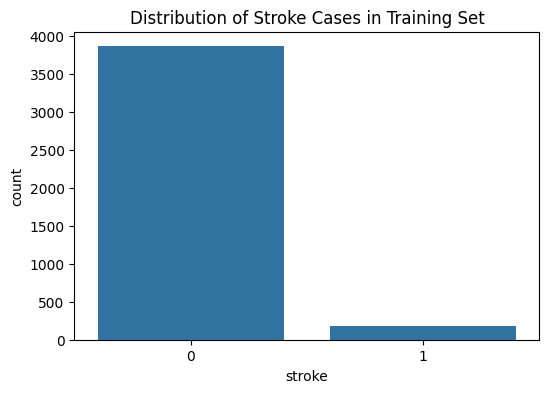

In [37]:
# check distrubtion of stroke in y_train and y_test by sns countplot
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title('Distribution of Stroke Cases in Training Set')

In [38]:
# make oversmapling for y_train to balance the data by using SMOTE from imblearn
# install imblearn by pip install imblearn
!pip install imblearn
from imblearn.over_sampling import SMOTE

Text(0.5, 1.0, 'Distribution of Stroke Cases in Resampled Training Set')

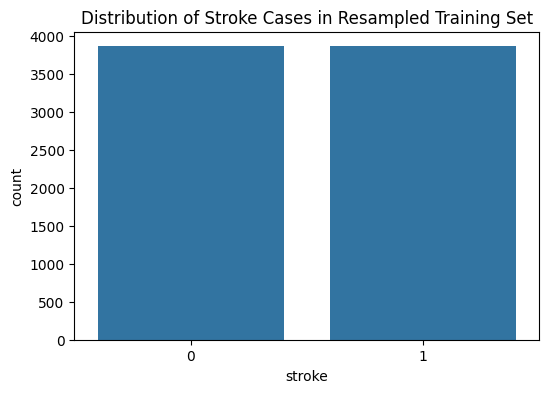

In [39]:
# make oversmapling for y_train to balance the data by using SMOTE from imblearn

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# show the count of each class in y_train_resampled
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled)
plt.title('Distribution of Stroke Cases in Resampled Training Set')